   # Trabajo Práctico 1 (2026 - 2do semestre)

In [21]:
import pandas as pd

df = pd.read_csv("datatelco_customer_churn.csv")

pd.to_numeric(df['TotalCharges'], errors='coerce')
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

# El problema con las columnas que no son reconocidas directamente como numéricas

Luego de investigar un poco, descubrimos que Pandas infiere el dtype al leer el CSV, columna por columna, y aplica una regla simple: si todos los valores de la columna se pueden convertir a número, la hace numérica pero si aparece aunque sea uno solo que no puede, toda la columna cae a object.Object significa que la columna no guarda los valores en sí, sino punteros a objetos de Python. En la práctica, casi siempre son strings.

El caso que encontramos fue con TotalCharges. Hay 7043 filas, de las cuales 7032 son montos perfectamente numéricos. Pero 11 tienen un espacio en blanco. Ese espacio no se puede convertir a número, así que pandas se rinde y guarda las 7043 como strings. Un "29.85" con comillas, no un 29.85.

Los espacios en blanco aparecen cuando son clientes con tenure = 0, o sea que recién se dieron de alta y todavía no facturaron nada. Esa columna sí es numérica conceptualmente, pero pandas la lee como object porque hay unas 11 filas con un string vacío (" ") en lugar de un número.

El impacto de no detectarlo es que la columna queda como texto y el modelo o la ignora, o si alguien la codifica como categórica, termina tratando cada monto como una categoría distinta.

Se arregla con pd.to_numeric(df['TotalCharges'], errors='coerce') y después tendríamos que decidir qué hacer con esos NaN (imputar con 0 tiene sentido acá, justificando que no facturaron todavía).

In [23]:
# 1. Conversión: los " " no parseables pasan a NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Verificación del diagnóstico (para dejar registro en el notebook)
faltantes = df['TotalCharges'].isna()
print(f"Filas con TotalCharges nulo: {faltantes.sum()}")
print(f"Valores de tenure en esas filas: {df.loc[faltantes, 'tenure'].unique()}")

# 3. Chequeo final
print(f"\nDtype: {df['TotalCharges'].dtype}")
print(f"Nulos restantes: {df['TotalCharges'].isna().sum()}")

df.dtypes

Filas con TotalCharges nulo: 11
Valores de tenure en esas filas: [0]

Dtype: float64
Nulos restantes: 11


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

## 2. Preprocesamiento y prevención de Data Leakage

### **Valores faltantes**

Compruebo que el único problema de datos faltantes en todo el dataset fue el de TotalCharges, lo cual se deja constancia a continuación.

In [24]:
# Nulos "reales" en todas las columnas
print(df.isnull().sum()[df.isnull().sum() > 0])

# Nulos compuestos por "texto raro" en columnas categóricas
for col in df.select_dtypes(include='object').columns:
    valores_raros = df[col].apply(lambda x: isinstance(x, str) and x.strip() == '').sum()
    if valores_raros > 0:
        print(f"{col}: {valores_raros} valores vacíos/espacios")

TotalCharges    11
dtype: int64


Para las filas con `TotalCharges` nulo y `tenure=0`, imputo con 0, ya que son clientes que recién se dieron de alta y todavía no generaron facturación acumulada.

Si quedaran filas con `TotalCharges` nulo y `tenure>0` (verificado arriba), esos casos se imputan luego (para evitar data leakage)

In [25]:
# Imputación condicional (justificada por lógica de negocio)
condicion_tenure_cero = (df['TotalCharges'].isna()) & (df['tenure'] == 0)
condicion_otros_nulos = (df['TotalCharges'].isna()) & (df['tenure'] != 0)

print(f"Nulos con tenure = 0: {condicion_tenure_cero.sum()}")
print(f"Nulos con tenure > 0: {condicion_otros_nulos.sum()}")

df.loc[condicion_tenure_cero, 'TotalCharges'] = 0

print(f"Nulos restantes en TotalCharges: {df['TotalCharges'].isna().sum()}")

Nulos con tenure = 0: 11
Nulos con tenure > 0: 0
Nulos restantes en TotalCharges: 0


In [26]:
# Imputación para el caso tenure=0: TotalCharges = 0 (lógica de negocio: el cliente todavía no facturó nada)
df.loc[condicion_tenure_cero, 'TotalCharges'] = 0

# Chequeo: cuántos nulos quedan sin resolver (los de tenure>0, si los hubiera)
print(f"Nulos restantes en TotalCharges: {df['TotalCharges'].isna().sum()}")

Nulos restantes en TotalCharges: 0


### **Variables categóricas**

Al revisar las categorías de las variables de texto, encontramos que varias columnas no son binarias en apariencia, pero sí lo son en esencia:

- `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`,`StreamingMovies` tienen 3 valores: `Yes`, `No`, `No internet service`.
- `MultipleLines` tiene 3 valores: `Yes`, `No`, `No phone service`.

El problema es que la tercera categoría no aporta información nueva: un cliente tiene `"No internet service"` en esas 6 columnas si y solo si `InternetService == "No"`, y tiene `"No phone service"` en `MultipleLines` si y solo si `PhoneService == "No"`. Es decir, esa categoría es perfectamente redundante con una variable que ya está en el dataset.

Por eso, decidimos colapsar `"No internet service"` y `"No phone service"` en `"No"`. Esto convierte a las 7 columnas mencionadas en verdaderamente binarias, permitiendo aplicar Label Encoding de forma consistente con el resto de las variables Yes/No, y sin perder información (porque esa información ya vive en `InternetService` y `PhoneService`).

In [27]:
# Colapsamos "No internet service" / "No phone service" en "No"
cols_no_internet = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_no_internet:
    df[col] = df[col].replace('No internet service', 'No')

df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

# Verificación
for col in cols_no_internet + ['MultipleLines']:
    print(f"{col}: {df[col].unique()}")

OnlineSecurity: ['No' 'Yes']
OnlineBackup: ['Yes' 'No']
DeviceProtection: ['No' 'Yes']
TechSupport: ['No' 'Yes']
StreamingTV: ['No' 'Yes']
StreamingMovies: ['No' 'Yes']
MultipleLines: ['No' 'Yes']


In [28]:
#Ahora aplico One Hot Encoding y Label Encoding a las columnas categóricas
from sklearn.preprocessing import LabelEncoder

# customerID es un identificador único por cliente, no una variable predictiva. Si no hacemos este paso, 
# el One-Hot Encoding lo trataría como una columna categórica
df = df.drop(columns=['customerID'])

# 1. Separamos las columnas categóricas en binarias (2 categorías) y multiclase (3+),
# dejando Churn afuera porque es el target y lo tratamos aparte
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('Churn')

binarias = [col for col in cat_cols if df[col].nunique() == 2]
multiclase = [col for col in cat_cols if df[col].nunique() > 2]

#Verificación
print("Binarias (Label Encoding):", binarias)
print("Multiclase (One-Hot Encoding):", multiclase)

Binarias (Label Encoding): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']
Multiclase (One-Hot Encoding): ['InternetService', 'Contract', 'PaymentMethod']


In [29]:
# 2. Label Encoding para las binarias
le = LabelEncoder()
mapeos = {}  # guardamos el mapeo de cada columna para dejar constancia

for col in binarias:
    df[col] = le.fit_transform(df[col])
    mapeos[col] = dict(zip(le.classes_, le.transform(le.classes_)))

for col, mapeo in mapeos.items():
    print(f"{col}: {mapeo}")

# 3. One-Hot Encoding para las que tienen 3 o más categorías 
df = pd.get_dummies(df, columns=multiclase, drop_first=True)

# 4. Encodeamos el target por separado (No -> 0, Yes -> 1)
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# 5. Chequeo final
print(df.dtypes.value_counts())
print(df.select_dtypes(include='object').columns)

# Convertimos columnas booleanas a enteros para mejor compatibilidad con modelos de ML
dummy_cols = df.select_dtypes(include='bool').columns
df[dummy_cols] = df[dummy_cols].astype(int)

gender: {'Female': np.int64(0), 'Male': np.int64(1)}
Partner: {'No': np.int64(0), 'Yes': np.int64(1)}
Dependents: {'No': np.int64(0), 'Yes': np.int64(1)}
PhoneService: {'No': np.int64(0), 'Yes': np.int64(1)}
MultipleLines: {'No': np.int64(0), 'Yes': np.int64(1)}
OnlineSecurity: {'No': np.int64(0), 'Yes': np.int64(1)}
OnlineBackup: {'No': np.int64(0), 'Yes': np.int64(1)}
DeviceProtection: {'No': np.int64(0), 'Yes': np.int64(1)}
TechSupport: {'No': np.int64(0), 'Yes': np.int64(1)}
StreamingTV: {'No': np.int64(0), 'Yes': np.int64(1)}
StreamingMovies: {'No': np.int64(0), 'Yes': np.int64(1)}
PaperlessBilling: {'No': np.int64(0), 'Yes': np.int64(1)}
int64      15
bool        7
float64     2
Name: count, dtype: int64
Index([], dtype='object')


### Orden de las operaciones: Train/Test Split antes del escalado

Un punto crítico en este pipeline es el **momento** en que se realiza la separación entre
entrenamiento y testeo en relación con el escalado (`StandardScaler`) y la imputación de
nulos.

**Decisión tomada:** el `train_test_split` se hizo *antes* de aplicar `StandardScaler`, y el
scaler se fiteó (`fit_transform`) únicamente sobre `X_train`. Al conjunto de test se le aplicó
solamente `transform`, usando la media y el desvío estándar ya calculados en train.

**¿Por qué en ese orden?** El objetivo del conjunto de test es simular datos "nuevos" que el
modelo nunca vio, para poder estimar honestamente cómo va a performar en producción. Si
calculáramos la media y el desvío de `StandardScaler` sobre el dataset completo (train + test)
antes de separar, esas estadísticas quedarían "contaminadas" con información del test set. El
modelo terminaría entrenándose sobre datos escalados con una referencia que incluye
información que, en un escenario real, no debería estar disponible en el momento de
entrenar.

Esto es un caso de **Data Leakage**: el modelo obtendría una ventaja artificial durante el
entrenamiento, lo cual se traduce en una evaluación optimista sobre el conjunto de test. Las
métricas de test dejarían de ser representativas del desempeño real, y ese problema recién se
notaría al desplegar el modelo con datos genuinamente nuevos, donde el desempeño caería
respecto a lo medido en el notebook.

**Evidencia en nuestros resultados:** al aplicar `describe()` sobre las columnas escaladas de
`X_train`, la media dio prácticamente 0 (`~1e-17`) y el desvío prácticamente 1, como es
esperable de un `StandardScaler` recién fiteado. En cambio, al hacer lo mismo sobre `X_test`,
la media dio valores cercanos a 0 pero no exactamente 0 (entre -0.02 y -0.04 según la
columna), y el desvío quedó levemente distinto de 1. Esto confirma que el test set fue
transformado con las estadísticas de train y no con las propias — si hubiéramos hecho
`fit_transform` también en test, la media hubiera dado ~0 exacto ahí también, y esa
"perfección" habría sido justamente la señal de que hubo leakage.

**Nota sobre la imputación:** en este dataset en particular, la imputación de `TotalCharges`
se resolvió con una regla de negocio (clientes con `tenure = 0` no facturaron nada, por lo
tanto `TotalCharges = 0`), que no depende de ninguna estadística calculada sobre los datos
(como la media o la mediana). Por eso no genera leakage, independientemente de si se aplica
antes o después del split. El riesgo de leakage por imputación existe cuando se usan
estadísticas del dataset (por ejemplo, imputar con la media/mediana de una columna): en esos
casos, esa estadística también debería calcularse solo sobre train, con la misma lógica que
el escalado.

## Datos de entrenamiento SIN escalar

Ojo con esto: en tu notebook, X_train ya quedó escalado a mano en el punto 2. Para el punto 3 necesitamos que el pipeline sea el que escale, así que le tenemos que dar los datos sin escalar. Como X (antes del split) nunca se escaló, simplemente rehacemos el split:

In [30]:
from sklearn.model_selection import train_test_split

# Rehacemos el split partiendo de X sin escalar.
# Con el MISMO random_state=42, las filas que caen en train y test son
# exactamente las mismas de antes (misma partición, reproducible).
X = df.drop(columns=['Churn'])   # todas las features (ya numéricas), SIN escalar
y = df['Churn']                  # el target: 0 = no se va, 1 = se va

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y # estratifica. Mantiene la misma proporción de "se va / no se va" en train y en test. 
)                                                    # Como tu clase está desbalanceada, esto importa.

## Armamos el preprocesador (el escalado por columnas)

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Las columnas numéricas continuas que SÍ hay que escalar
cols_numericas = ['tenure', 'MonthlyCharges', 'TotalCharges']

# ColumnTransformer: aplica StandardScaler solo a esas 3 columnas.
# El resto (binarias y dummies) pasa sin cambios gracias a remainder='passthrough'.
preprocesador = ColumnTransformer(
    transformers=[('escalado', StandardScaler(), cols_numericas)],
    remainder='passthrough'
)

## Acá armamos el Pipeline completo (preprocesado + modelo)

* steps=[...]: la secuencia de pasos, en orden. Cada paso es una tupla (nombre, objeto).
    - Primero 'preprocesamiento' → el ColumnTransformer de la celda B (escala las numéricas).
    - Después 'modelo' → la regresión logística.
* LogisticRegression(...): crea el clasificador.
    - max_iter=1000: la regresión logística encuentra sus pesos mediante un proceso iterativo (va mejorando de a pasos hasta "converger", o sea hasta que deja de mejorar). El valor por defecto (100 pasos) a veces no alcanza y tira un warning de "no convergió". Subirlo a 1000 le da margen para terminar tranquilo. No cambia el concepto, solo evita el warning.
    - random_state=42: semilla, para reproducibilidad del propio modelo.

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('modelo', LogisticRegression(max_iter=1000, random_state=42))
])

## Definimos el esquema de K-Fold estratificado

* StratifiedKFold: la versión de K-Fold que mantiene la proporción de clases en cada fold. Como tu Churn está desbalanceado, es la correcta (y la consigna te pide justificar justo esto).
* n_splits=5: los 5 folds que pide el TP (la "K" de K-Fold).
* shuffle=True: baraja las filas antes de cortar. Sin esto, cortaría los folds en el orden en que vienen las filas, y si el dataset tuviera algún orden oculto, los folds
saldrían sesgados. Barajar lo evita.
* random_state=42: semilla, para que el barajado sea siempre igual (reproducible).

In [33]:
from sklearn.model_selection import StratifiedKFold

# 5 folds, estratificado (respeta la proporción de clases en cada fold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Ejecutamos la validación cruzada

Acá es donde por fin corre todo. Usamos una función que hace el loop de las 5 rondas por nosotros:

In [34]:
from sklearn.model_selection import cross_validate

# Las métricas que queremos medir en cada fold
metricas = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

resultados = cross_validate(
    pipeline,      # la cadena escalado+modelo que armamos
    X_train,       # features de entrenamiento (SIN escalar: el pipeline escala)
    y_train,       # target de entrenamiento
    cv=skf,        # el esquema de 5 folds estratificados
    scoring=metricas
)

## Resumimos: promedio y desvío por métrica

* valores.mean(): el promedio de los 5 folds → tu estimación de qué tan bien generaliza.
* valores.std(): el desvío estándar → qué tan parejo fue entre folds. Chico = estable; grande = sensible a la partición.
* El :.4f es solo formato (4 decimales).

In [35]:
for m in metricas:
    valores = resultados['test_' + m]   # los 5 valores de esta métrica
    print(f"{m:12s}: {valores.mean():.4f}  (+/- {valores.std():.4f})")

accuracy    : 0.8025  (+/- 0.0124)
precision   : 0.6541  (+/- 0.0281)
recall      : 0.5431  (+/- 0.0411)
f1          : 0.5928  (+/- 0.0304)
roc_auc     : 0.8460  (+/- 0.0126)


Por qué K-Fold en vez de un simple Holdout: "Holdout" es apartar un solo pedazo para validar, una sola vez. El problema es que tu estimación depende de qué filas cayeron en ese pedazo (suerte). K-Fold usa todas las filas para validar (cada una una vez, a lo largo de las 5 rondas) y promedia, dando una estimación más robusta y menos dependiente del azar. Además, al reportar el desvío, ves cuán estable es el modelo.

Por qué Stratified K-Fold: tu Churn está desbalanceado (bastante más "No" que "Yes"). Con un K-Fold común, por azar un fold podría quedar con muy pocos "Yes", y su validación sería poco representativa (y métricas como Precision/Recall se volverían inestables). Estratificar fuerza a que cada fold tenga la misma proporción de clases que el total, así cada ronda evalúa sobre una muestra representativa.

# 4. Evaluación del modelo base
Entrenamos el pipeline completo (escalado + Regresión Logística) sobre **todo** el conjunto de entrenamiento (`X_train`, las mismas ~5634 filas usadas en el K-Fold, pero ahora sin partirlas en folds), y lo evaluamos una única vez sobre el conjunto de testeo (`X_test`), que el modelo no vio en ningún momento del proceso anterior.

In [36]:
# Entrenamos el pipeline (preprocesamiento + modelo) sobre TODO el train set
pipeline.fit(X_train, y_train)

# Predecimos sobre el test set (el pipeline aplica el mismo escalado fiteado en train)
y_pred = pipeline.predict(X_test)

Accuracy : 0.8055
Precision: 0.6582
Recall   : 0.5561
F1-Score : 0.6029


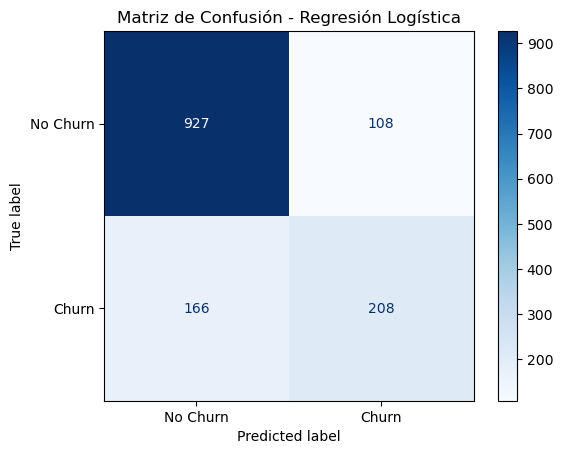

In [37]:
from sklearn.metrics import (confusion_matrix, accuracy_score,
                              precision_score, recall_score, f1_score,
                              ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión - Regresión Logística')
plt.show()

In [38]:
# Modelo naive: predice siempre la clase mayoritaria en el train set
clase_mayoritaria = y_train.mode()[0]
y_pred_naive = [clase_mayoritaria] * len(y_test)

acc_naive = accuracy_score(y_test, y_pred_naive)
print(f"Distribución de clases en test: {y_test.value_counts(normalize=True).to_dict()}")
print(f"Accuracy del modelo naive (predice siempre '{clase_mayoritaria}'): {acc_naive:.4f}")

Distribución de clases en test: {0: 0.7345635202271115, 1: 0.2654364797728886}
Accuracy del modelo naive (predice siempre '0'): 0.7346


### ¿Es el Accuracy una buena métrica para este problema?

El dataset está desbalanceado: aproximadamente 73.5% de los clientes no se da de baja (`Churn = No`) contra 26.5% que sí (`Churn = Yes`). Esto significa que un modelo "naive" que
prediga siempre la clase mayoritaria (`No`), sin aprender absolutamente nada del problema, obtiene un Accuracy de aproximadamente 73.5% — muy cercano al Accuracy real de nuestro modelo de Regresión Logística.

Esto deja en evidencia que el Accuracy **no es una buena métrica por sí sola** para este problema: un número alto de Accuracy puede estar ocultando que el modelo es malo prediciendo la clase minoritaria (`Churn = Yes`), que es justamente la clase que le interesa a la empresa para poder actuar (ofrecer descuentos, retener clientes, etc.). Un modelo que "acierta mucho" en términos globales puede seguir siendo inútil desde el punto de vista de negocio si falla sistemáticamente en detectar a los clientes que realmente se van a ir.

Por eso, en este contexto conviene mirar Precision, Recall y F1-Score específicamente sobre la clase `Churn = Yes` (que es la clase positiva/minoritaria), y no solo el Accuracy general. La matriz de confusión también es clave: nos permite ver cuántos verdaderos positivos (clientes que se iban y el modelo detectó) versus falsos negativos (clientes que se iban y el modelo no detectó) hay, algo que el Accuracy por sí solo no distingue.

# 5. Análisis de Negocio e Impacto de las Métricas

In [39]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Mismo preprocesador (escalado) que usamos antes, mismo modelo (Regresión Logística)
pipeline_smote = ImbPipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('smote', SMOTE(random_state=42)),
    ('modelo', LogisticRegression(max_iter=1000, random_state=42))
])

# Entrenamos sobre TODO el train set (SMOTE actúa acá, generando muestras sintéticas
# de la clase minoritaria SOLO dentro del entrenamiento)
pipeline_smote.fit(X_train, y_train)

# Predecimos sobre test SIN SMOTE (el pipeline sabe que en predict no se aplica SMOTE,
# solo el escalado + el modelo ya entrenado). Test mantiene su desbalance real.
y_pred_smote = pipeline_smote.predict(X_test)

Accuracy : 0.7374
Precision: 0.5034
Recall   : 0.7968
F1-Score : 0.6170


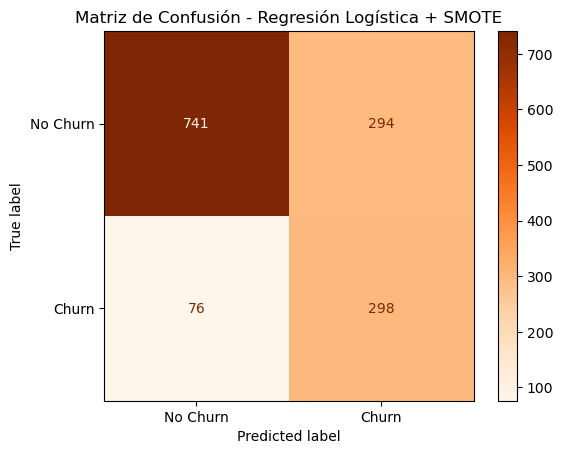

In [40]:
cm_smote = confusion_matrix(y_test, y_pred_smote)

acc_smote = accuracy_score(y_test, y_pred_smote)
prec_smote = precision_score(y_test, y_pred_smote)
rec_smote = recall_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)

print(f"Accuracy : {acc_smote:.4f}")
print(f"Precision: {prec_smote:.4f}")
print(f"Recall   : {rec_smote:.4f}")
print(f"F1-Score : {f1_smote:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Oranges', values_format='d')
plt.title('Matriz de Confusión - Regresión Logística + SMOTE')
plt.show()

Buena pregunta, vale la pena entenderlo bien porque es la base de la discusión de negocio del ejercicio 5.

## Qué le pasa al modelo sin SMOTE

Con el dataset desbalanceado (73.5% No / 26.5% Yes), una Regresión Logística que minimiza el error global aprende que "predecir No casi siempre" es una estrategia bastante buena en términos de Accuracy — porque acertar la clase mayoritaria pesa mucho más en el promedio. El resultado es un modelo **conservador**: solo predice `Churn = Yes` cuando está muy seguro, porque tiene pocos ejemplos de esa clase para aprender bien sus patrones y "cuesta más" arriesgarse a esa predicción.

Eso significa:
- Pocos Falsos Positivos (rara vez dice "se va" si en realidad no se iba) → Precision alta.
- Pero también se le escapan bastantes churners reales, porque es cauteloso → Recall más bajo.

## Qué cambia con SMOTE

SMOTE genera ejemplos sintéticos de la clase minoritaria hasta emparejarla con la mayoritaria (en `X_train`). Ahora el modelo ve, durante el entrenamiento, una proporción ~50/50 en vez de 73.5/26.5. Como consecuencia:

- El modelo deja de tener el "incentivo" de ignorar la clase minoritaria — ya no le conviene tanto default-ear a "No", porque en los datos que ve durante el entrenamiento el Yes pesa igual.
- Aprende una frontera de decisión menos conservadora, que clasifica como `Yes` a más casos.

Esto tiene un efecto directo y casi mecánico sobre las dos métricas:
- **Recall sube**: al ser menos conservador, atrapa más de los verdaderos churners que antes se le escapaban (menos Falsos Negativos).
- **Precision baja**: pero esa misma "agresividad" hace que también empiece a marcar como `Yes` a algunos clientes que en realidad no se iban a ir (más Falsos Positivos).

En el fondo es un **trade-off del umbral de decisión implícito**: SMOTE no hace que el modelo "sepa más", sino que desplaza dónde traza la línea entre "predigo Yes" y "predigo No" — la corre hacia predecir Yes con más frecuencia. Ganás sensibilidad (Recall) a costa de especificidad (Precision). Es exactamente el mismo tipo de trade-off que se puede lograr bajando el umbral de probabilidad de 0.5 a, digamos, 0.3 — pero SMOTE lo logra reequilibrando los datos en vez de tocar el umbral directamente.

Este es justo el ángulo que te sirve para conectar con la pregunta de negocio: si el descuento es barato, este trade-off (más Recall, menos Precision) te conviene, porque preferís pecar de agresivo con las ofertas. Si el descuento es caro, este mismo trade-off te juega en contra.

# Parte ||

In [ ]:
# Nuevo target: tenure binarizado (1 = cliente establecido >12 meses, 0 = cliente nuevo)
df['tenure_establecido'] = (df['tenure'] > 12).astype(int)

#Vemos cuál es la proporción de clientes establecidos y nuevos en el dataset
print(df['tenure_establecido'].value_counts(normalize=True))

# X: sacamos tenure (ahora redundante con el target) Y Churn (para no filtrar el problema original)
X_p2 = df.drop(columns=['tenure', 'tenure_establecido', 'Churn'])
y_p2 = df['tenure_establecido']

X_train_p2, X_test_p2, y_train_p2, y_test_p2 = train_test_split(
    X_p2, y_p2, test_size=0.2, random_state=42, stratify=y_p2
)

tenure_establecido
1    0.689621
0    0.310379
Name: proportion, dtype: float64


In [42]:
# Ya no escalamos 'tenure' (es el target ahora), solo las numéricas que quedan
cols_numericas_p2 = ['MonthlyCharges', 'TotalCharges']

preprocesador_p2 = ColumnTransformer(
    transformers=[('escalado', StandardScaler(), cols_numericas_p2)],
    remainder='passthrough'
)

# Modelo simple, out-of-the-box: sin tuning, sin K-Fold, config default (+max_iter para que converja)
pipeline_p2 = Pipeline(steps=[
    ('preprocesamiento', preprocesador_p2),
    ('modelo', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_p2.fit(X_train_p2, y_train_p2)
y_pred_p2 = pipeline_p2.predict(X_test_p2)

Accuracy : 0.9872
Precision: 0.9938
Recall   : 0.9877
F1-Score : 0.9907


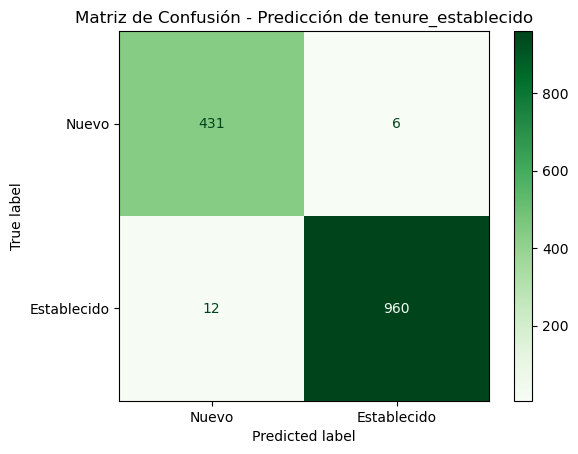

In [43]:
cm_p2 = confusion_matrix(y_test_p2, y_pred_p2)

acc_p2 = accuracy_score(y_test_p2, y_pred_p2)
prec_p2 = precision_score(y_test_p2, y_pred_p2)
rec_p2 = recall_score(y_test_p2, y_pred_p2)
f1_p2 = f1_score(y_test_p2, y_pred_p2)

print(f"Accuracy : {acc_p2:.4f}")
print(f"Precision: {prec_p2:.4f}")
print(f"Recall   : {rec_p2:.4f}")
print(f"F1-Score : {f1_p2:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm_p2, display_labels=['Nuevo', 'Establecido'])
disp.plot(cmap='Greens', values_format='d')
plt.title('Matriz de Confusión - Predicción de tenure_establecido')
plt.show()